In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
import numpy as np # 导入Numpy
import pandas as pd # 导入Pandas
import os # 导入os工具
print(os.listdir("/kaggle/input/datasets/jessicali9530/stanford-dogs-dataset/images/Images"))

['n02091635-otterhound', 'n02102318-cocker_spaniel', 'n02101388-Brittany_spaniel', 'n02088094-Afghan_hound', 'n02085936-Maltese_dog', 'n02104365-schipperke', 'n02100877-Irish_setter', 'n02086079-Pekinese', 'n02099601-golden_retriever', 'n02100583-vizsla', 'n02102177-Welsh_springer_spaniel', 'n02093256-Staffordshire_bullterrier', 'n02106166-Border_collie', 'n02093991-Irish_terrier', 'n02109961-Eskimo_dog', 'n02110958-pug', 'n02105412-kelpie', 'n02094433-Yorkshire_terrier', 'n02097474-Tibetan_terrier', 'n02089867-Walker_hound', 'n02110627-affenpinscher', 'n02113186-Cardigan', 'n02102040-English_springer', 'n02089973-English_foxhound', 'n02098286-West_Highland_white_terrier', 'n02095570-Lakeland_terrier', 'n02087394-Rhodesian_ridgeback', 'n02101006-Gordon_setter', 'n02098413-Lhasa', 'n02099429-curly-coated_retriever', 'n02088364-beagle', 'n02108551-Tibetan_mastiff', 'n02102480-Sussex_spaniel', 'n02109525-Saint_Bernard', 'n02087046-toy_terrier', 'n02113799-standard_poodle', 'n02107683-Bern

In [10]:
# 本示例咱只处理这10种狗吧
dir = '/kaggle/input/datasets/jessicali9530/stanford-dogs-dataset/images/Images/' 
chihuahua_dir = dir+'n02085620-Chihuahua' #吉娃娃
japanese_spaniel_dir = dir+'n02085782-Japanese_spaniel' #日本狆
maltese_dir = dir+'n02085936-Maltese_dog' #马尔济斯犬
pekinese_dir = dir+'n02086079-Pekinese' #北京狮子狗
shitzu_dir = dir+'n02086240-Shih-Tzu' #西施犬
blenheim_spaniel_dir = dir+'n02086646-Blenheim_spaniel' #英国可卡犬
papillon_dir = dir+'n02086910-papillon' #蝴蝶犬
toy_terrier_dir = dir+'n02087046-toy_terrier' #玩具猎狐梗
afghan_hound_dir = dir+'n02088094-Afghan_hound' #阿富汗猎犬
basset_dir = dir+'n02088238-basset' #巴吉度猎犬

In [12]:
import cv2 # 导入Open CV工具箱
X = []
y_label = []
imgsize = 150
# 定义一个函数读入狗狗图片
def training_data(label,data_dir):
    print ("正在读入：", data_dir)
    for img in os.listdir(data_dir):
        path = os.path.join(data_dir,img)
        img = cv2.imread(path,cv2.IMREAD_COLOR)
        img = cv2.resize(img,(imgsize,imgsize))
        X.append(np.array(img))
        y_label.append(str(label)) 
# 读入10个目录中的狗狗图片
training_data('chihuahua',chihuahua_dir)
training_data('japanese_spaniel',japanese_spaniel_dir)
training_data('maltese',maltese_dir)
training_data('pekinese',pekinese_dir)
training_data('shitzu',shitzu_dir)
training_data('blenheim_spaniel',blenheim_spaniel_dir)
training_data('papillon',papillon_dir)
training_data('toy_terrier',toy_terrier_dir)
training_data('afghan_hound',afghan_hound_dir)
training_data('basset',basset_dir)

正在读入： /kaggle/input/datasets/jessicali9530/stanford-dogs-dataset/images/Images/n02085620-Chihuahua
正在读入： /kaggle/input/datasets/jessicali9530/stanford-dogs-dataset/images/Images/n02085782-Japanese_spaniel
正在读入： /kaggle/input/datasets/jessicali9530/stanford-dogs-dataset/images/Images/n02085936-Maltese_dog
正在读入： /kaggle/input/datasets/jessicali9530/stanford-dogs-dataset/images/Images/n02086079-Pekinese
正在读入： /kaggle/input/datasets/jessicali9530/stanford-dogs-dataset/images/Images/n02086240-Shih-Tzu
正在读入： /kaggle/input/datasets/jessicali9530/stanford-dogs-dataset/images/Images/n02086646-Blenheim_spaniel
正在读入： /kaggle/input/datasets/jessicali9530/stanford-dogs-dataset/images/Images/n02086910-papillon
正在读入： /kaggle/input/datasets/jessicali9530/stanford-dogs-dataset/images/Images/n02087046-toy_terrier
正在读入： /kaggle/input/datasets/jessicali9530/stanford-dogs-dataset/images/Images/n02088094-Afghan_hound
正在读入： /kaggle/input/datasets/jessicali9530/stanford-dogs-dataset/images/Images/n02088238-ba

In [13]:
from sklearn.preprocessing import LabelEncoder # 导入标签编码工具
from tensorflow.keras.utils import to_categorical # 导入One-hot编码工具
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_label) # 标签编码
y = to_categorical(y,10) # 将标签转换为One-hot编码
X = np.array(X) # 将X从列表转换为张量数组
X = X/255 # 将X张量归一化

In [14]:
print ('X张量的形状：', X.shape)
print ('X张量的第一个数据：', X[1])

X张量的形状： (1922, 150, 150, 3)
X张量的第一个数据： [[[0.89803922 0.8627451  0.81176471]
  [0.89019608 0.85490196 0.80392157]
  [0.94117647 0.90196078 0.85490196]
  ...
  [0.82352941 0.79215686 0.7372549 ]
  [0.82745098 0.8        0.72156863]
  [0.83137255 0.79607843 0.69411765]]

 [[0.92941176 0.89411765 0.84313725]
  [0.9254902  0.89019608 0.83921569]
  [0.93333333 0.89803922 0.84705882]
  ...
  [0.82352941 0.8        0.7254902 ]
  [0.82745098 0.80392157 0.71372549]
  [0.84705882 0.81568627 0.70588235]]

 [[0.9254902  0.89019608 0.83921569]
  [0.93333333 0.89803922 0.84705882]
  [0.89411765 0.85882353 0.80784314]
  ...
  [0.82352941 0.80784314 0.71372549]
  [0.82745098 0.81176471 0.69803922]
  [0.83529412 0.81176471 0.68235294]]

 ...

 [[0.65098039 0.69411765 0.7254902 ]
  [0.70196078 0.74509804 0.77647059]
  [0.70588235 0.74901961 0.78039216]
  ...
  [0.74901961 0.81960784 0.84705882]
  [0.7372549  0.80784314 0.83529412]
  [0.72941176 0.8        0.82745098]]

 [[0.69411765 0.7372549  0.76862745

In [15]:
print ('y张量的形状：', y.shape)
print ('y张量的第一个数据：', y[1])

y张量的形状： (1922, 10)
y张量的第一个数据： [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]


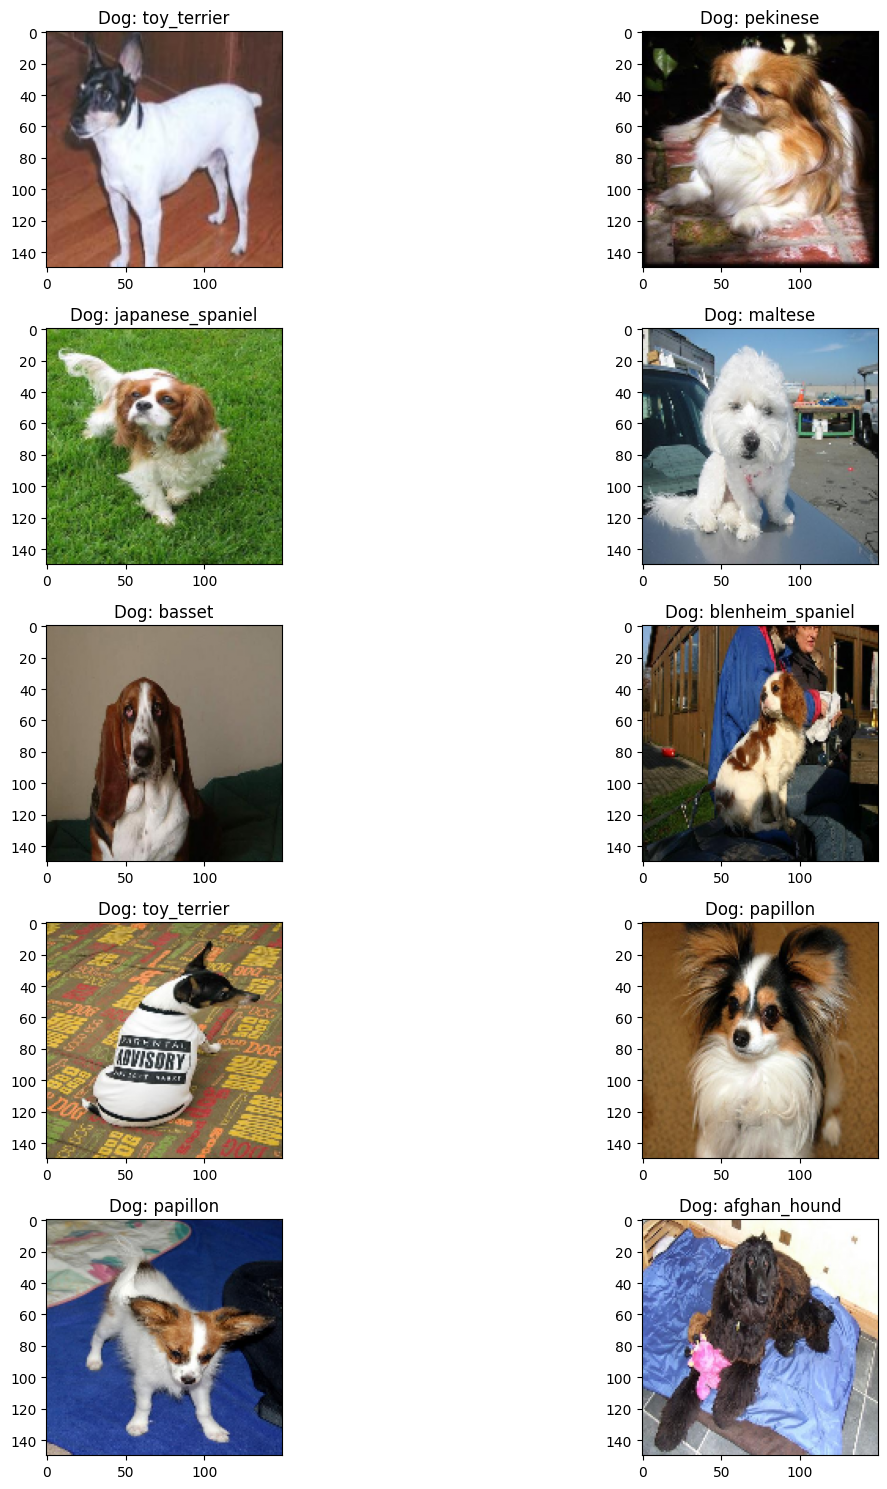

In [16]:
import matplotlib.pyplot as plt # 导入matplotlib
import random as rdm # 导入随机数工具
# 随机显示几张可爱的狗狗图片吧
fig,ax = plt.subplots(5,2)
fig.set_size_inches(15,15)
for i in range(5):
    for j in range (2):
        r = rdm.randint(0,len(X))
        X[r] = X[r][...,::-1] #将图像通道从BGR调整为RGB，防止色彩失真
        ax[i,j].imshow(X[r])
        ax[i,j].set_title('Dog: '+y_label[r])
plt.tight_layout()

In [18]:
from sklearn.model_selection import train_test_split # 导入拆分工具
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,
                                                 random_state=0)

In [21]:
from keras import layers # 导入所有层
from keras import models # 导入所有模型
cnn = models.Sequential() # 贯序模型
cnn.add(layers.Conv2D(32, (3, 3), activation='relu', # 卷积
                        input_shape=(150, 150, 3))) 
cnn.add(layers.MaxPooling2D((2, 2))) # 最大池化
cnn.add(layers.Conv2D(64, (3, 3), activation='relu')) # 卷积
cnn.add(layers.MaxPooling2D((2, 2))) # 最大池化
cnn.add(layers.Conv2D(128, (3, 3), activation='relu')) # 卷积
cnn.add(layers.MaxPooling2D((2, 2))) # 最大池化
cnn.add(layers.Conv2D(128, (3, 3), activation='relu')) # 卷积
cnn.add(layers.MaxPooling2D((2, 2))) # 最大池化
cnn.add(layers.Flatten()) # 展平
cnn.add(layers.Dense(512, activation='relu')) # 全连接
cnn.add(layers.Dense(10, activation='softmax')) # 分类输出
cnn.compile(loss='categorical_crossentropy', # 损失函数
            optimizer='RMSprop', # 优化器
            metrics=['acc']) # 评估指标

In [23]:
history = cnn.fit(X_train,y_train, # 指定训练集
                    epochs=50,     # 指定轮次
                    batch_size=256, # 指定批量大小
                    validation_data=(X_test,y_test)) # 指定验证集

Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 38s 5s/step - acc: 0.1776 - loss: 2.2006 - val_acc: 0.0935 - val_loss: 3.5828
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 38s 5s/step - acc: 0.2075 - loss: 2.4198 - val_acc: 0.1429 - val_loss: 2.2310
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 42s 6s/step - acc: 0.1906 - loss: 2.1686 - val_acc: 0.1870 - val_loss: 2.2236
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 41s 6s/step - acc: 0.2310 - loss: 2.1350 - val_acc: 0.1792 - val_loss: 2.2498
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 39s 5s/step - acc: 0.2069 - loss: 2.1529 - val_acc: 0.1325 - val_loss: 2.2751
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 40s 6s/step - acc: 0.2121 - loss: 2.1561 - val_acc: 0.1429 - val_loss: 2.5831
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 38s 5s/step - acc: 0.2310 - loss: 2.1542 - val_acc: 0.2104 - val_loss: 2.1627
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 40s 6s/step - acc: 0.2843 - loss: 2.0374 - val_acc: 0.1403 - val_loss: 2.9059
Epoch 9/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 38s 5s/step - acc: 0.2049 - loss: 2.2618 - val_acc: 

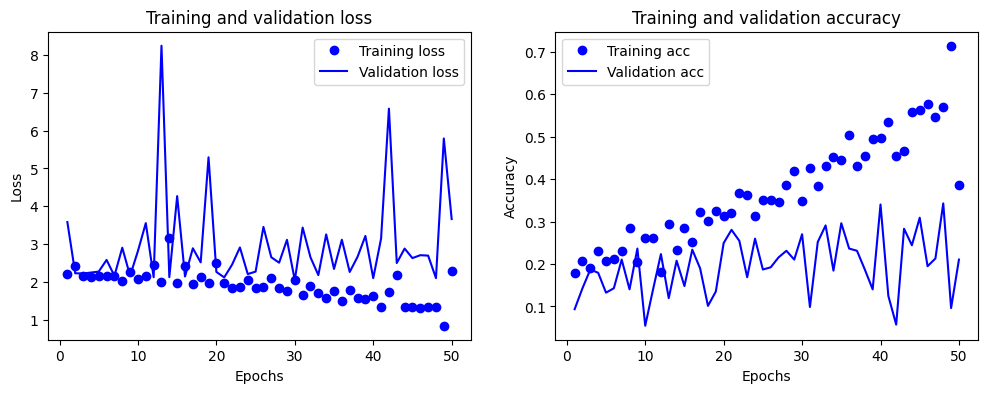

In [24]:
# 这段代码参考《Python深度学习》一书中的学习曲线的实现
def show_history(history): # 显示训练过程中的学习曲线
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(loss) + 1)
    plt.figure(figsize=(12,4))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss, 'bo', label='Training loss')
    plt.plot(epochs, val_loss, 'b', label='Validation loss')
    plt.title('Training and validation loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    acc = history.history['acc']
    val_acc = history.history['val_acc']
    plt.subplot(1, 2, 2)
    plt.plot(epochs, acc, 'bo', label='Training acc')
    plt.plot(epochs, val_acc, 'b', label='Validation acc')
    plt.title('Training and validation accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()
show_history(history) # 调用这个函数，并将神经网络训练历史数据作为参数输入

## 调整优化器

In [26]:
from tensorflow.keras import optimizers # 导入优化器
cnn = models.Sequential() # 序贯模型
cnn.add(layers.Conv2D(32, (3, 3), activation='relu', # 卷积
                       input_shape=(150, 150, 3))) 
cnn.add(layers.MaxPooling2D((2, 2))) # 最大池化
cnn.add(layers.Conv2D(64, (3, 3), activation='relu')) # 卷积
cnn.add(layers.Dropout(0.5)) # Dropout
cnn.add(layers.MaxPooling2D((2, 2))) # 最大池化
cnn.add(layers.Conv2D(128, (3, 3), activation='relu')) # 卷积
cnn.add(layers.Dropout(0.5)) # Dropout
cnn.add(layers.MaxPooling2D((2, 2))) # 最大池化
cnn.add(layers.Conv2D(256, (3, 3), activation='relu')) # 卷积
cnn.add(layers.MaxPooling2D((2, 2))) # 最大池化
cnn.add(layers.Flatten()) # 展平
cnn.add(layers.Dropout(0.5)) # Dropout
cnn.add(layers.Dense(512, activation='relu')) # 全连接
cnn.add(layers.Dense(10, activation='sigmoid')) # 分类输出
cnn.compile(loss='categorical_crossentropy', # 损失函数
            optimizer=optimizers.Adam(learning_rate=1e-4), # 更新优化器并设定学习速率
            metrics=['acc']) # 评估指标
history = cnn.fit(X_train,y_train, # 指定训练集
                  epochs=50,     # 指定轮次
                  batch_size=256, # 指定批量大小
                  validation_data=(X_test,y_test)) # 指定验证集

Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 51s 7s/step - acc: 0.1132 - loss: 2.3221 - val_acc: 0.1065 - val_loss: 2.2987
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 48s 7s/step - acc: 0.1457 - loss: 2.2906 - val_acc: 0.1429 - val_loss: 2.2905
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 49s 7s/step - acc: 0.1444 - loss: 2.2791 - val_acc: 0.1688 - val_loss: 2.2862
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 50s 7s/step - acc: 0.1633 - loss: 2.2525 - val_acc: 0.1636 - val_loss: 2.2872
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 80s 7s/step - acc: 0.1561 - loss: 2.2559 - val_acc: 0.1506 - val_loss: 2.2860
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 48s 7s/step - acc: 0.1724 - loss: 2.2358 - val_acc: 0.1844 - val_loss: 2.2807
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 48s 7s/step - acc: 0.1464 - loss: 2.2665 - val_acc: 0.1351 - val_loss: 2.2784
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 83s 7s/step - acc: 0.1796 - loss: 2.2285 - val_acc: 0.1558 - val_loss: 2.2780
Epoch 9/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 47s 7s/step - acc: 0.1457 - loss: 2.2353 - val_acc: 

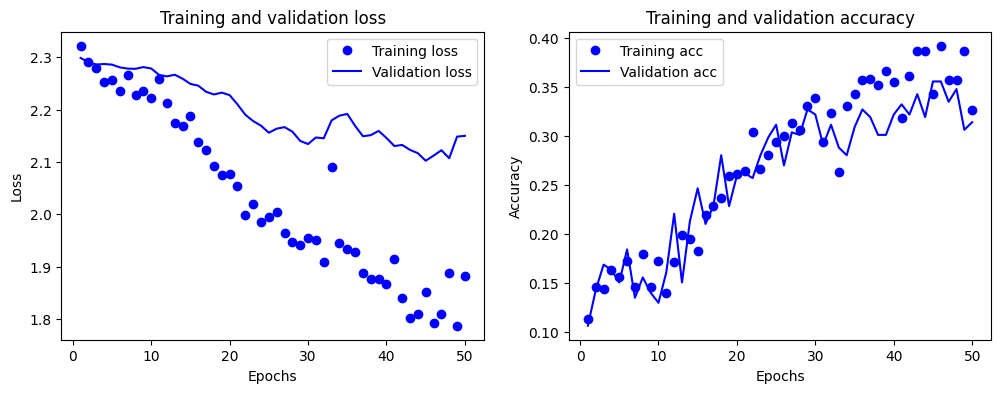

In [27]:
show_history(history)

## 添加Dropout层

In [ ]:
cnn = models.Sequential() # 序贯模型
cnn.add(layers.Conv2D(32, (3, 3), activation='relu', # 卷积
                       input_shape=(150, 150, 3))) 
cnn.add(layers.MaxPooling2D((2, 2))) # 最大池化
cnn.add(layers.Conv2D(64, (3, 3), activation='relu')) # 卷积
cnn.add(layers.Dropout(0.5)) # Dropout
cnn.add(layers.MaxPooling2D((2, 2))) # 最大池化
cnn.add(layers.Conv2D(128, (3, 3), activation='relu')) # 卷积
cnn.add(layers.Dropout(0.5)) # Dropout
cnn.add(layers.MaxPooling2D((2, 2))) # 最大池化
cnn.add(layers.Conv2D(256, (3, 3), activation='relu')) # 卷积
cnn.add(layers.MaxPooling2D((2, 2))) # 最大池化
cnn.add(layers.Flatten()) # 展平
cnn.add(layers.Dropout(0.5)) # Dropout
cnn.add(layers.Dense(512, activation='relu')) # 全连接
cnn.add(layers.Dense(10, activation='sigmoid')) # 分类输出
cnn.compile(loss='categorical_crossentropy', # 损失函数
            optimizer=optimizers.Adam(learning_rate=1e-4), # 更新优化器并设定学习速率
            metrics=['acc']) # 评估指标
history = cnn.fit(X_train,y_train, # 指定训练集
                  epochs=50,     # 指定轮次
                  batch_size=256, # 指定批量大小
                  validation_data=(X_test,y_test)) # 指定验证集

Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 55s 7s/step - acc: 0.1327 - loss: 2.3148 - val_acc: 0.1844 - val_loss: 2.2893
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 48s 7s/step - acc: 0.1529 - loss: 2.2735 - val_acc: 0.2104 - val_loss: 2.2866
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 46s 6s/step - acc: 0.1750 - loss: 2.2478 - val_acc: 0.2104 - val_loss: 2.2815
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 48s 7s/step - acc: 0.1796 - loss: 2.2302 - val_acc: 0.1688 - val_loss: 2.2757
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 48s 7s/step - acc: 0.2082 - loss: 2.2086 - val_acc: 0.1922 - val_loss: 2.2755
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 45s 6s/step - acc: 0.1770 - loss: 2.2176 - val_acc: 0.1818 - val_loss: 2.2663
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 48s 7s/step - acc: 0.1952 - loss: 2.1889 - val_acc: 0.2312 - val_loss: 2.2592
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 48s 7s/step - acc: 0.1809 - loss: 2.2020 - val_acc: 0.2286 - val_loss: 2.2608
Epoch 9/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 46s 6s/step - acc: 0.2264 - loss: 2.1545 - val_acc: 

## 数据增强

In [ ]:
# 定义一个数据增强器，并设定各种增强选项
from keras.preprocessing.image import ImageDataGenerator
augs_gen = ImageDataGenerator(
           featurewise_center=False,
           samplewise_center=False,         
           featurewise_std_normalization=False,          
           samplewise_std_normalization=False,  
           zca_whitening=False, 
           rotation_range=10,  
           zoom_range = 0.1, 
           width_shift_range=0.2,  
           height_shift_range=0.2,
           horizontal_flip=True,  
           vertical_flip=False) 
augs_gen.fit(X_train) # 针对训练集拟合数据增强器

In [ ]:
history = cnn.fit( # 使用fit_generator
    augs_gen.flow(X_train,y_train,batch_size=16), # 增强后的训练集
#     validation_data  = (X_test,y_test), # 指定验证集
#     validation_steps = 100, # 指定验证步长
    steps_per_epoch  = 100, # 指定每轮步长
    epochs = 50,  # 指定轮次
    verbose = 1) # 指定是否显示训练过程中的信息